In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from IPython.display import display
from pandas.plotting import parallel_coordinates
from sklearn.decomposition import PCA

In [108]:
%matplotlib inline

In [109]:
path = kagglehub.dataset_download("ibriiee/video-games-sales-dataset-2022-updated-extra-feat")

print("Path to dataset files:", path)

Path to dataset files: /Users/ad/.cache/kagglehub/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat/versions/1


In [110]:
df2 = pd.read_csv('Video_Games.csv')
df2.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
NA_region = df2.groupby('Platform')['NA_Sales'].sum().sort_values(ascending=False)

NA_region.plot(kind='bar', figsize=(12,6), title='Sales in NA by platform')
plt.ylabel('Sales (in millions of USD)')
plt.xlabel('Platform')

Text(0.5, 0, 'Platform')

In [112]:
EU_region = df2.groupby('Platform')['EU_Sales'].sum().sort_values(ascending=False)

EU_region.plot(kind='bar', figsize=(12,6), title='Sales in EU by platform')
plt.ylabel('Sales (in millions of USD)')
plt.xlabel('Platform')

Text(0.5, 13.597222222222209, 'Platform')

## Platform Sales Overview
This section examines how sales are distributed across gaming platforms and highlights the platforms with the strongest global performance.

In [113]:
unique_platforms = df2['Platform'].unique()
unique_platforms_count = len(unique_platforms)
print(unique_platforms)
print(unique_platforms_count)

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
31


In [114]:
platform_sales = df2.groupby('Platform')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum()
print(platform_sales)

          NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
Platform                                                         
2600         90.60      5.47      0.00         0.91         97.08
3DO           0.00      0.00      0.10         0.00          0.10
3DS          83.49     61.48    100.67        13.36        259.09
DC            5.43      1.69      8.56         0.27         15.97
DS          382.67    188.89    175.57        59.28        807.10
GB          114.32     47.82     85.12         8.20        255.45
GBA         187.54     75.25     47.33         7.73        318.50
GC          133.46     38.71     21.58         5.18        199.36
GEN          21.05      6.05      2.70         0.97         30.78
GG            0.00      0.00      0.04         0.00          0.04
N64         139.02     41.06     34.22         4.38        218.88
NES         125.94     21.15     98.65         5.31        251.07
NG            0.00      0.00      1.44         0.00          1.44
PC        

In [115]:
regional_sales = df2.groupby('Platform')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

regional_sales = regional_sales.loc[regional_sales.sum(axis=1).sort_values(ascending=False).index]

regional_sales.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20c')

plt.title('Regional Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Sales (in millions of USD)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()

In [116]:
NA_region = df2.groupby('Platform')['NA_Sales'].sum().sort_values(ascending=False)

NA_region.plot(kind='bar', figsize=(12,6), title='Sales in NA by platform')
plt.ylabel('Sales (in millions of USD)')
plt.xlabel('Platform')

Text(0.5, 28.99999999999998, 'Platform')

In [117]:
EU_region = df2.groupby('Platform')['EU_Sales'].sum().sort_values(ascending=False)

EU_region.plot(kind='bar', figsize=(12,6), title='Sales in EU by platform')
plt.ylabel('Sales (in millions of USD)')
plt.xlabel('Platform')

Text(0.5, 7.9186811966772215, 'Platform')

In [118]:
JP_region = df2.groupby('Platform')['JP_Sales'].sum().sort_values(ascending=False)

JP_region.plot(kind='bar', figsize=(12,6), title='Sales in JP by platform')
plt.ylabel('Sales (in millions of USD)')
plt.xlabel('Platform')

Text(0.5, 7.9186811966772215, 'Platform')

In [119]:
JP_region = df2.groupby('Platform')['JP_Sales'].sum().sort_values(ascending=False)

JP_region.plot(kind='bar', figsize=(12,6), title='Sales in JP by platform')
plt.ylabel('Sales (in millions of USD)')
plt.xlabel('Platform')

Text(0.5, 7.9186811966772215, 'Platform')

In [120]:
df_sales = df2[['Platform', 'Global_Sales']].copy()

platform_counts = df_sales['Platform'].value_counts()
df_sales = df_sales[df_sales['Platform'].isin(platform_counts[platform_counts > 30].index)]

df_sales = df_sales[df_sales['Global_Sales'] > 0]

plt.figure(figsize=(16, 8))

sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', palette='coolwarm')

plt.title('Distribution of Global Sales by Platform')
plt.xlabel('Global Sales (in millions of USD)')
plt.ylabel('Platform')
plt.xticks(rotation=45)

/var/folders/k7/t32643cn28qc5hpk99j57v_c0000gn/T/ipykernel_20572/187082355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', palette='coolwarm')


(array([-20.,   0.,  20.,  40.,  60.,  80., 100.]),
 [Text(-20.0, 0, '−20'),
  Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100')])

In [121]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', palette='coolwarm', showfliers=False)

plt.title('Distribution of Global Sales by Platform')
plt.xlabel('Global Sales (in millions of USD)')
plt.ylabel('Platform')
plt.xticks(rotation=45)

/var/folders/k7/t32643cn28qc5hpk99j57v_c0000gn/T/ipykernel_20572/3746307482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', palette='coolwarm', showfliers=False)


(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5]),
 [Text(-0.5, 0, '−0.5'),
  Text(0.0, 0, '0.0'),
  Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5')])

## Regional Genre Performance
This section compares how major game genres perform across North America, Europe, Japan, and other markets.

In [122]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', palette='coolwarm')

plt.title('Distribution of Global Sales by Platform')
plt.xlabel('Global Sales (in millions of USD)')
plt.ylabel('Platform')
plt.xticks(rotation=45)
plt.xscale('log')

/var/folders/k7/t32643cn28qc5hpk99j57v_c0000gn/T/ipykernel_20572/1440912723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', palette='coolwarm')


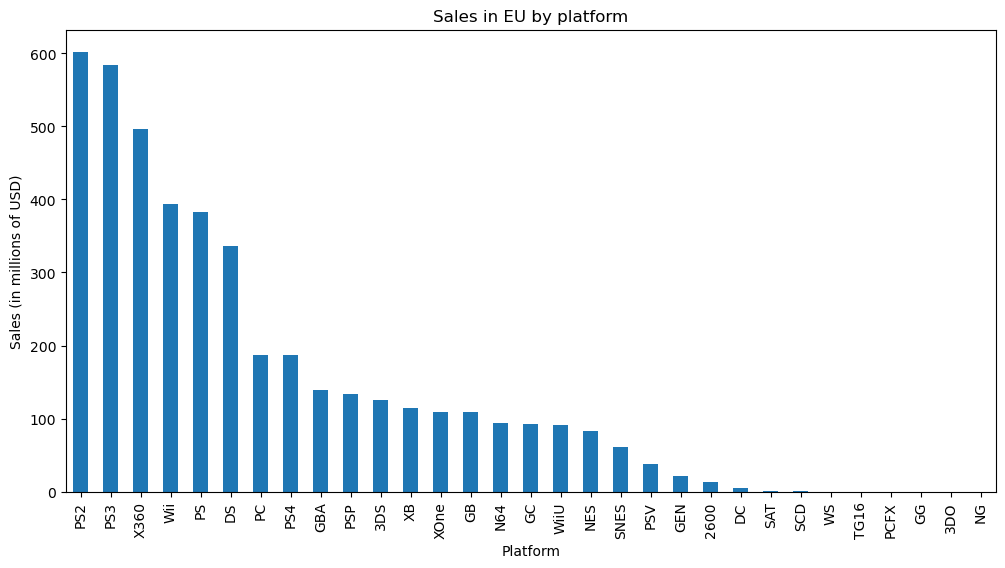

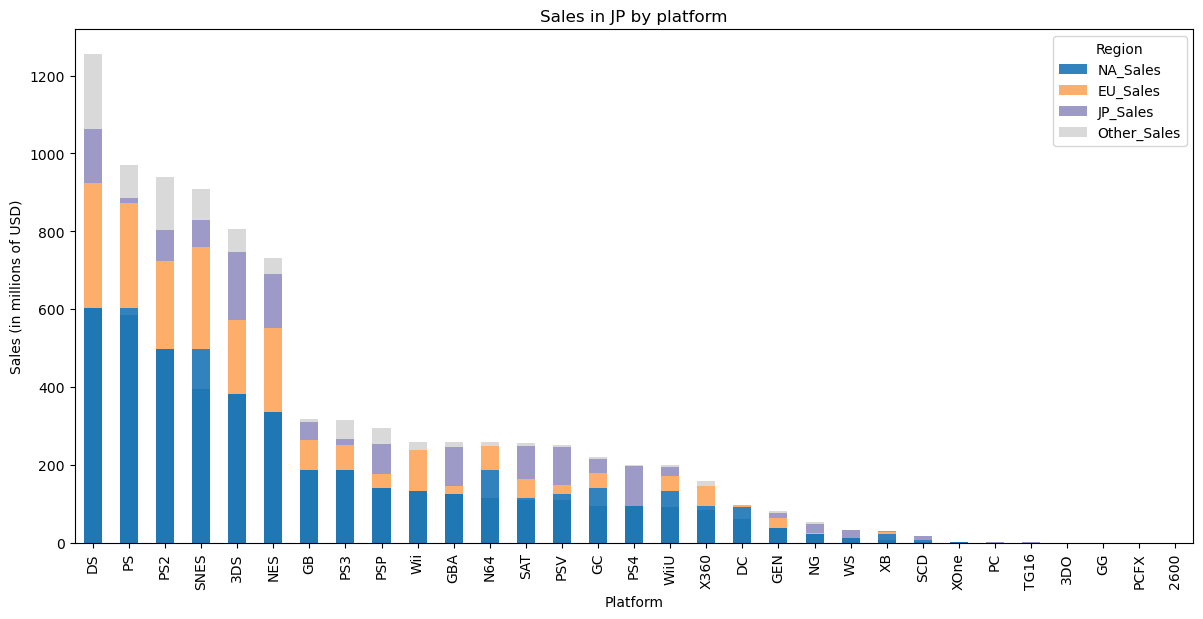

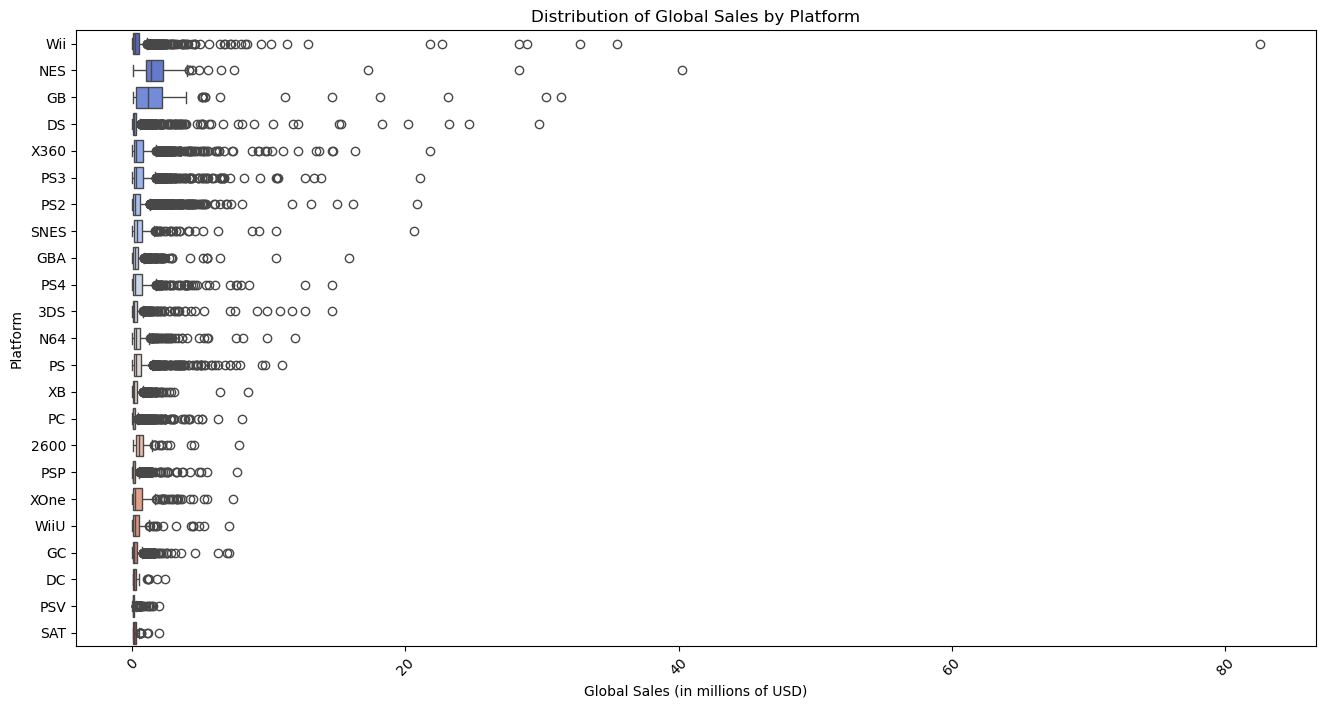

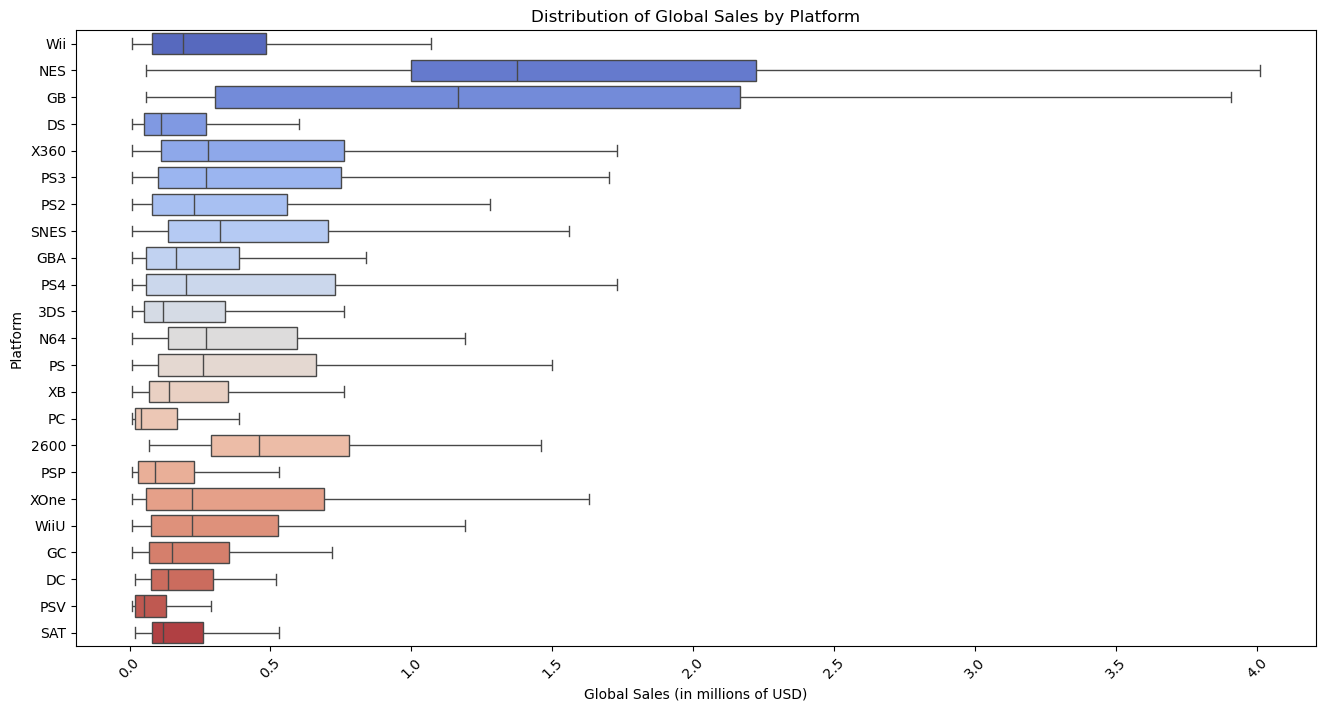

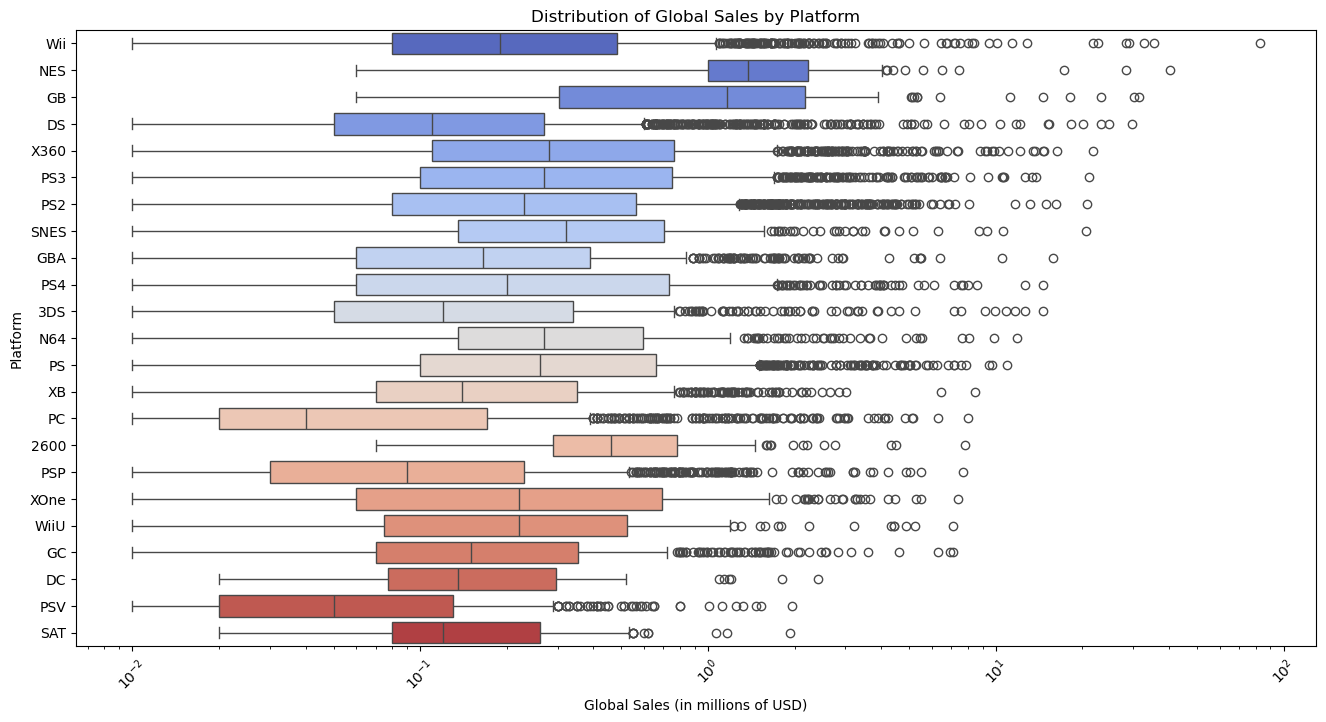

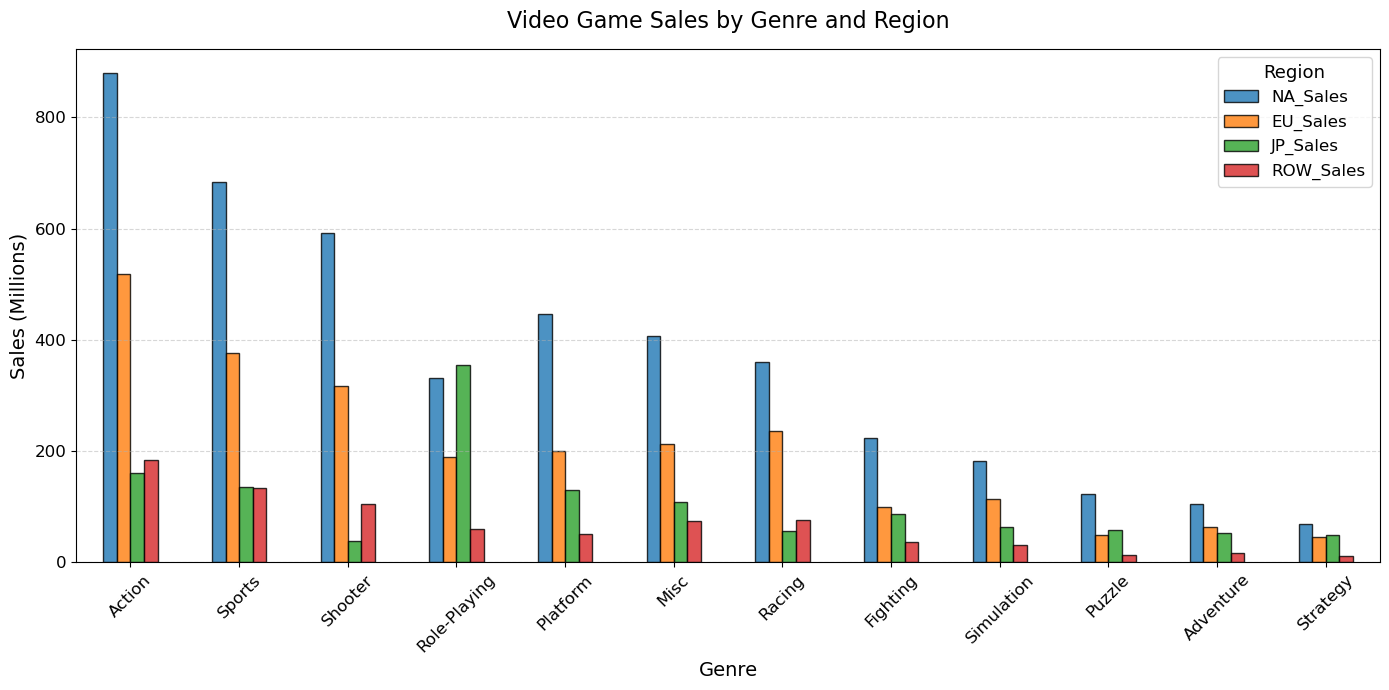

In [123]:
if 'genre_sales' not in globals():
    genre_sales = (
        df2
        .groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
        .sum()
        .reset_index()
        .rename(columns={'Other_Sales': 'ROW_Sales'})
    )

ax = genre_sales.set_index('Genre')[['NA_Sales','EU_Sales','JP_Sales','ROW_Sales']]\
    .plot(
        kind='bar', figsize=(14,7),
        alpha=0.8, edgecolor='k'
    )

ax.set_ylabel('Sales (Millions)', fontsize=14)
ax.set_xlabel('Genre', fontsize=14)
ax.set_title('Video Game Sales by Genre and Region', fontsize=16, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Region', fontsize=12, title_fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

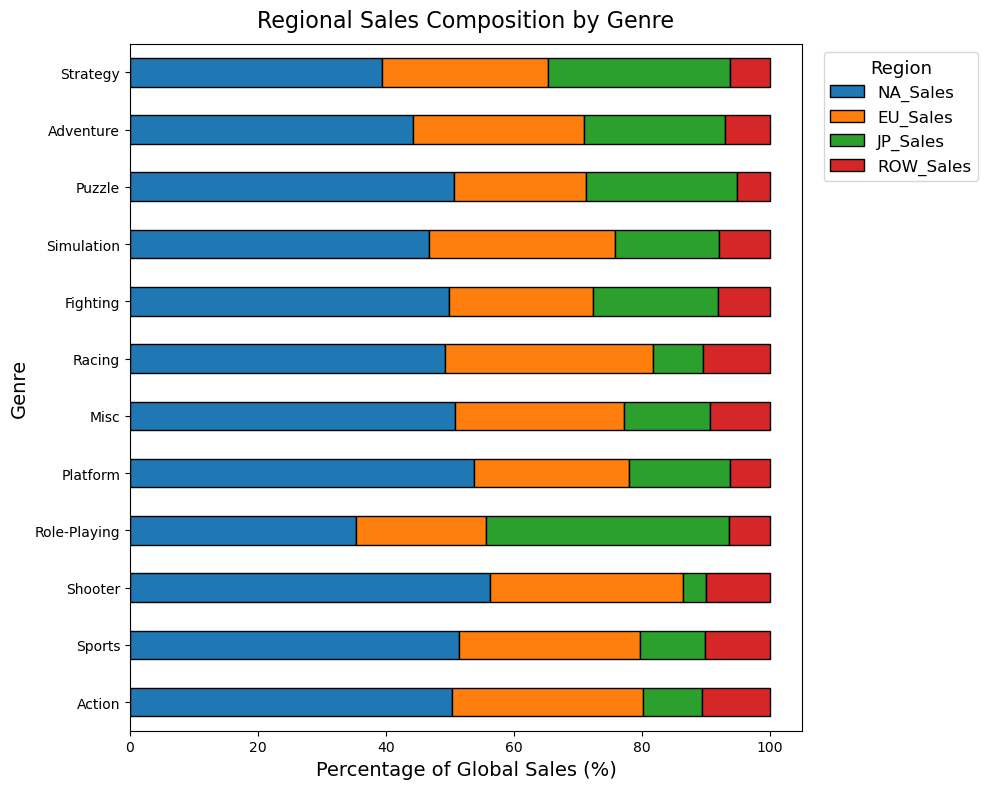

In [124]:
#  Percentage share per genre

# Calculate percentage share of regional sales within each genre
# Ensure 'Global_Sales' is calculated and available in genre_sales
percent_share = genre_sales.set_index('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'ROW_Sales']].div(genre_sales.set_index('Genre')['Global_Sales'], axis=0) * 100

ax = percent_share.plot(
    kind='barh', stacked=True,
    figsize=(10,8), edgecolor='k'
)
ax.set_xlabel('Percentage of Global Sales (%)', fontsize=14)
ax.set_ylabel('Genre', fontsize=14)
ax.set_title('Regional Sales Composition by Genre', fontsize=16, pad=12)
ax.legend(title='Region', fontsize=12, title_fontsize=13, bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

| Metric          |   Missing Count |   Missing % |
|:----------------|----------------:|------------:|
| User_Count      |            9129 |       54.6  |
| Critic_Score    |            8582 |       51.33 |
| Critic_Count    |            8582 |       51.33 |
| Rating          |            6769 |       40.49 |
| User_Score      |            6704 |       40.1  |
| Developer       |            6623 |       39.61 |
| Year_of_Release |             269 |        1.61 |
| Publisher       |              54 |        0.32 |
| Name            |               2 |        0.01 |
| Genre           |               2 |        0.01 |


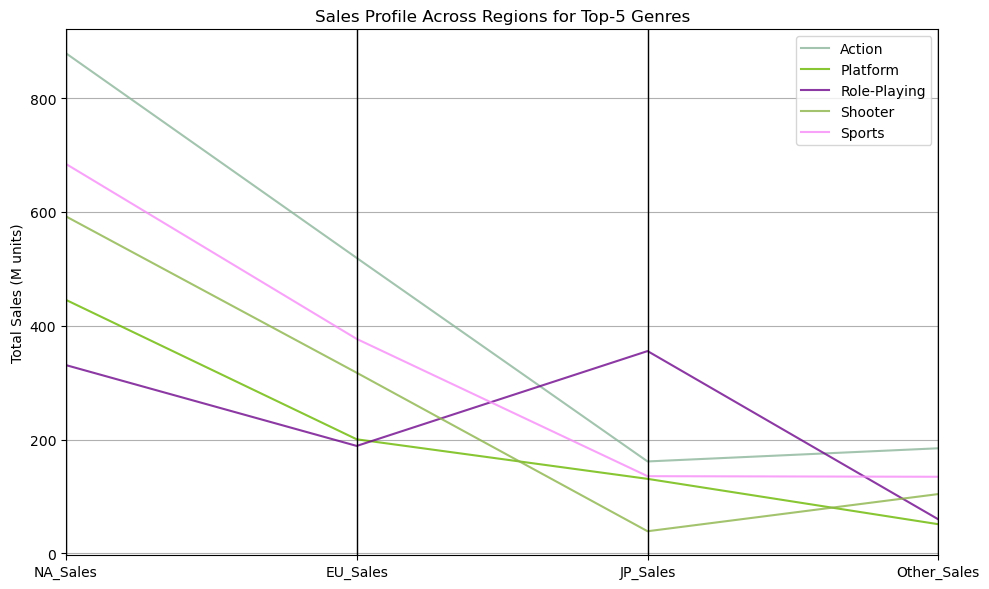

In [125]:
def clean_video_games(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop_duplicates().reset_index(drop=True).copy()
    return df

# Loading & clean
raw_df = df2  # or wherever your raw DataFrame lives
df_clean = clean_video_games(raw_df)

#  Missing-data audit as a Markdown table
missing = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(2)
audit = pd.DataFrame({
    'Metric': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
audit_nonzero = audit[audit['Missing Count'] > 0].copy()
audit_nonzero['Missing %'] = audit_nonzero['Missing %'].map(lambda x: f"{x:.2f}")

print(audit_nonzero.to_markdown(index=False))

# Identifiying top-5 genres by total global sales
top5 = (
    df_clean
      .groupby('Genre')['Global_Sales']
      .sum()
      .nlargest(5)
      .index
)

pc_data = (
    df_clean[df_clean['Genre'].isin(top5)]
      .groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,6))
parallel_coordinates(
    pc_data,
    class_column='Genre',
    cols=['NA_Sales','EU_Sales','JP_Sales','Other_Sales'],
    alpha=0.8
)
plt.title('Sales Profile Across Regions for Top-5 Genres')
plt.ylabel('Total Sales (M units)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [126]:
# Updated to resolve FutureWarning
sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', hue='Platform', palette='coolwarm', legend=False)

<Axes: xlabel='Global_Sales', ylabel='Platform'>

In [127]:
# Updated to resolve FutureWarning
sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', hue='Platform', palette='coolwarm', showfliers=False, legend=False)

<Axes: xlabel='Global_Sales', ylabel='Platform'>

In [128]:
# Updated to resolve FutureWarning
sns.boxplot(data=df_sales, y='Platform', x='Global_Sales', hue='Platform', palette='coolwarm', legend=False)

<Axes: xlabel='Global_Sales', ylabel='Platform'>

## Sales Trends Over Time
This section tracks how video game sales change across release years and highlights long-term market patterns.

In [129]:
genre_sales = (
    df2
    .groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]
    .sum()
    .reset_index()
    .rename(columns={'Other_Sales':'ROW_Sales'})
)

genre_sales['Global_Sales'] = genre_sales[['NA_Sales','EU_Sales','JP_Sales','ROW_Sales']].sum(axis=1)
genre_sales = (
    genre_sales
    .sort_values('Global_Sales', ascending=False)
    .reset_index(drop=True)
)

genre_sales[['NA_Sales','EU_Sales','JP_Sales','ROW_Sales','Global_Sales']] = \
    genre_sales[['NA_Sales','EU_Sales','JP_Sales','ROW_Sales','Global_Sales']].round(1)

print(genre_sales)

           Genre  NA_Sales  EU_Sales  JP_Sales  ROW_Sales  Global_Sales
0         Action     879.0     519.1     161.4      184.6        1744.2
1         Sports     684.4     376.8     135.5      134.5        1331.3
2        Shooter     592.2     317.3      38.8      104.1        1052.4
3   Role-Playing     330.8     188.7     355.5       59.6         934.6
4       Platform     445.5     200.4     130.8       51.1         827.8
5           Misc     407.3     212.7     108.1       74.4         802.5
6         Racing     359.4     236.5      56.7       76.1         728.7
7       Fighting     223.4     100.3      87.5       36.4         447.5
8     Simulation     182.2     113.5      63.8       30.8         390.3
9         Puzzle     122.9      50.0      57.3       12.4         242.6
10     Adventure     105.3      63.5      52.3       16.5         237.6
11      Strategy      68.6      45.2      49.7       10.8         174.2


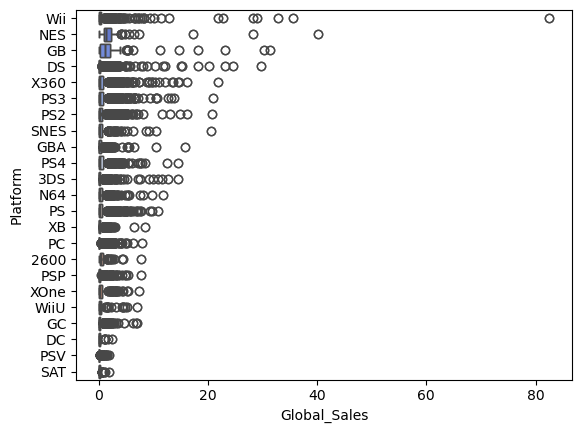

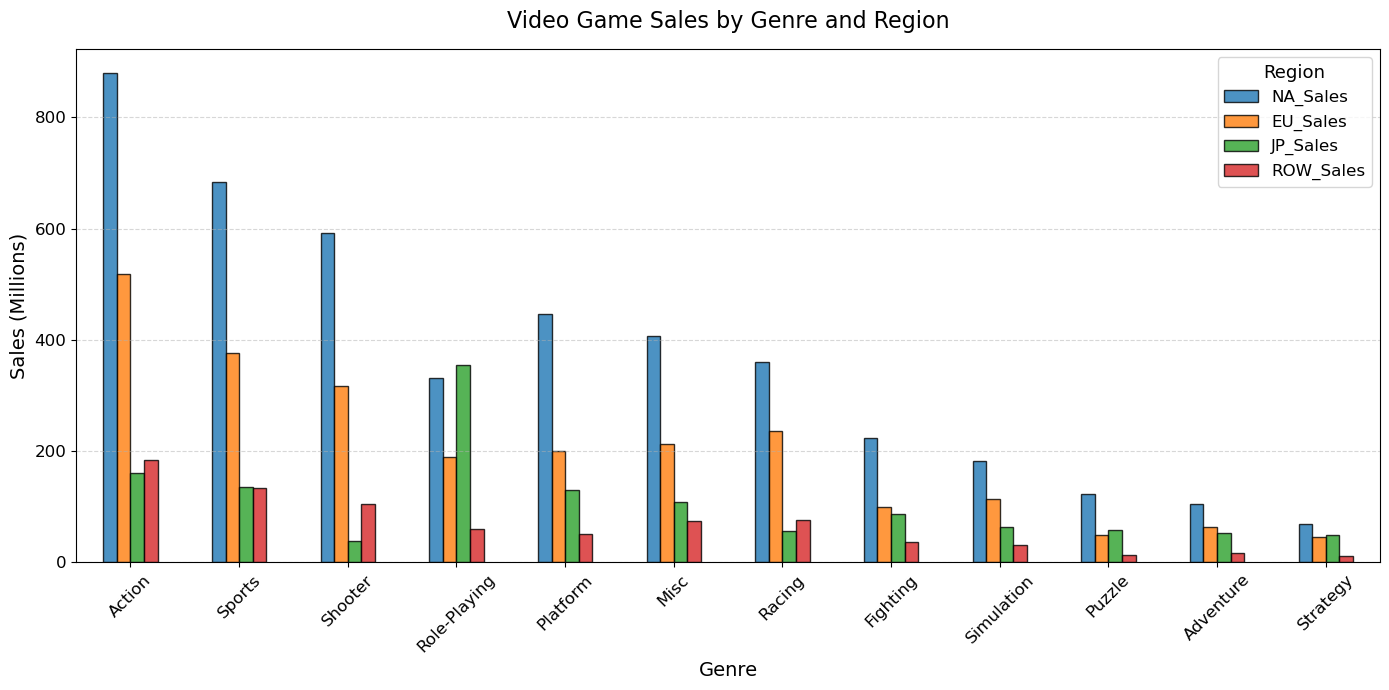

In [130]:
ax = genre_sales.set_index('Genre')[['NA_Sales','EU_Sales','JP_Sales','ROW_Sales']]\
    .plot(
        kind='bar', figsize=(14,7),
        alpha=0.8, edgecolor='k',
    )

ax.set_ylabel('Sales (Millions)', fontsize=14)
ax.set_xlabel('Genre', fontsize=14)
ax.set_title('Video Game Sales by Genre and Region', fontsize=16, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Region', fontsize=12, title_fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

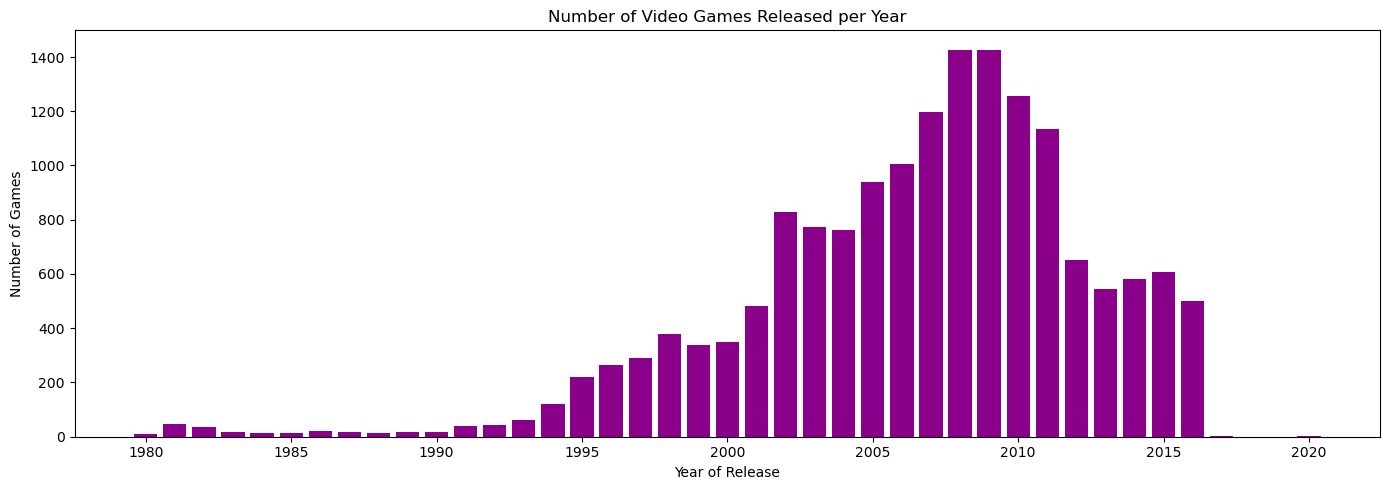

In [131]:
# Games released per year
games_per_year = df_clean.groupby('Year_of_Release').size()
plt.figure(figsize=(14,5))
plt.bar(games_per_year.index, games_per_year.values, color='darkmagenta')
plt.title('Number of Video Games Released per Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()

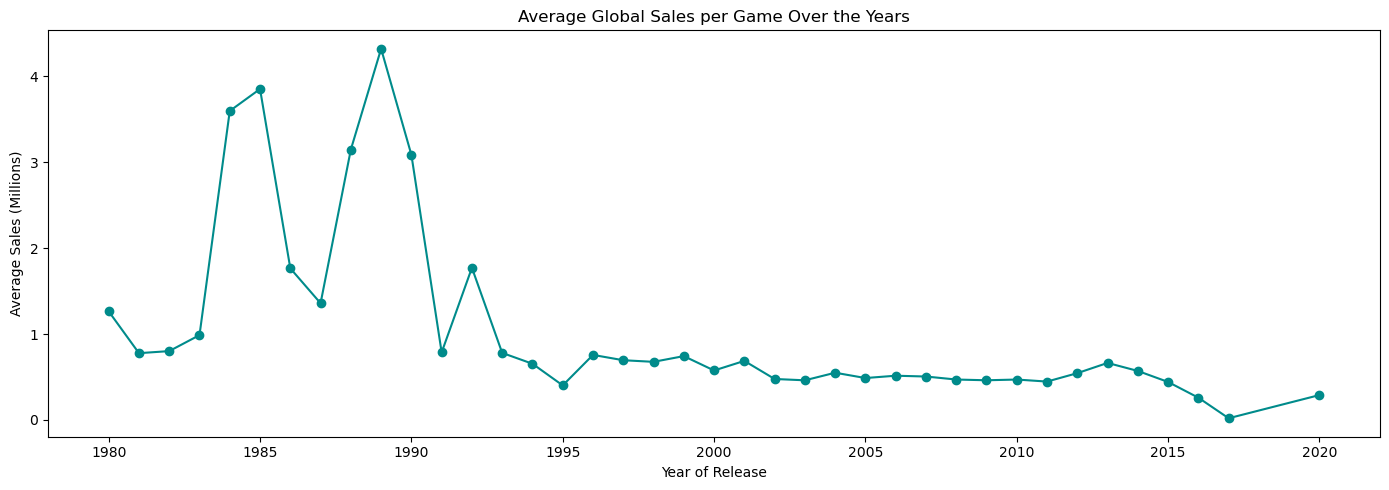

In [132]:
# Average sales per game (yearly sales / games per year)
yearly_sales = (
    df2.dropna(subset=['Year_of_Release'])
       .groupby('Year_of_Release', as_index=False)['Global_Sales']
       .sum()
       .sort_values('Year_of_Release')
)

avg_sales_per_game = (
    yearly_sales.set_index('Year_of_Release')['Global_Sales']
    .div(games_per_year)
    .values
)
plt.figure(figsize=(14,5))
plt.plot(yearly_sales['Year_of_Release'], avg_sales_per_game, marker='o', color='darkcyan')
plt.title('Average Global Sales per Game Over the Years')
plt.xlabel('Year of Release')
plt.ylabel('Average Sales (Millions)')
plt.tight_layout()
plt.show()

## Sales Trends Over Time
This section tracks how video game sales change across release years and highlights long-term market patterns.

In [133]:
df_clean = df2[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score']].dropna()
df_clean.shape

(8137, 6)

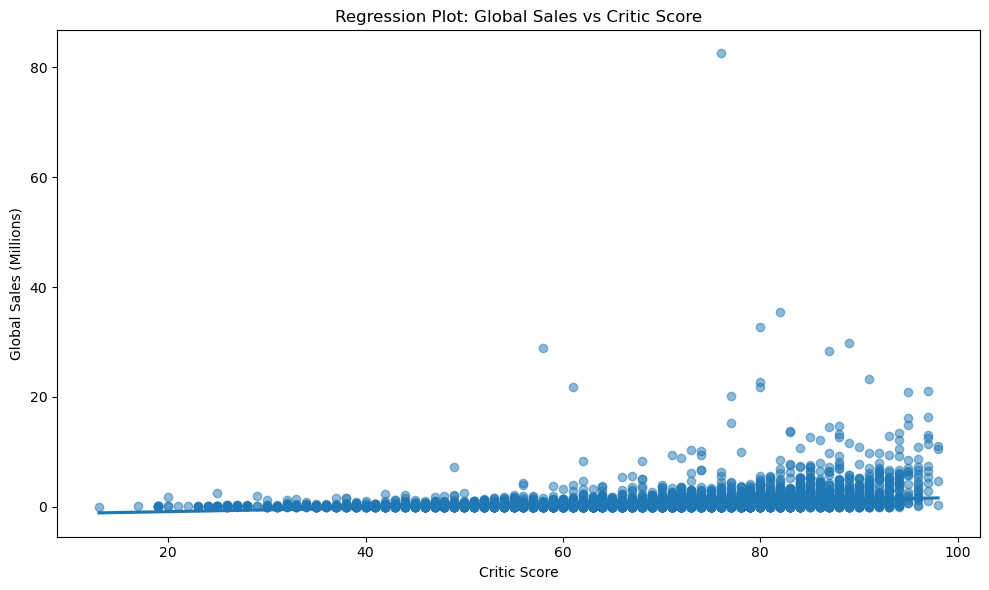

In [134]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='Critic_Score', y='Global_Sales', scatter_kws={'alpha': 0.5})
plt.title('Regression Plot: Global Sales vs Critic Score')
plt.xlabel('Critic Score')
plt.ylabel('Global Sales (Millions)')
plt.tight_layout()
plt.show()

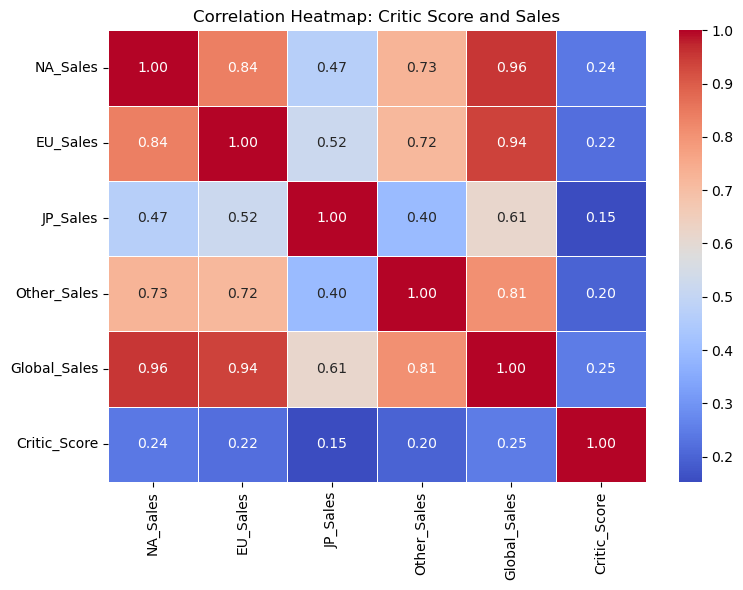

In [135]:
correlation = df_clean.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: Critic Score and Sales')
plt.tight_layout()
plt.show()

In [136]:
bins = [0, 50, 70, 80, 100]
labels = ['Poor', 'Average', 'Good', 'Excellent']
df_clean['Score_Bin'] = pd.cut(df_clean['Critic_Score'], bins=bins, labels=labels)

/var/folders/k7/t32643cn28qc5hpk99j57v_c0000gn/T/ipykernel_20572/1583091481.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_sales_by_bin = df_clean.groupby('Score_Bin')['Global_Sales'].sum()


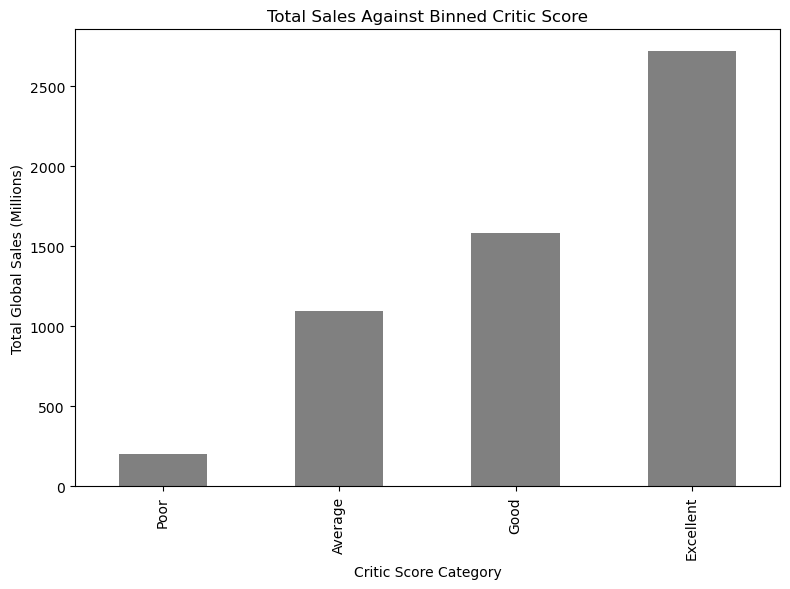

In [137]:
total_sales_by_bin = df_clean.groupby('Score_Bin')['Global_Sales'].sum()
total_sales_by_bin.plot(kind='bar', figsize=(8, 6), color='gray')
plt.title('Total Sales Against Binned Critic Score')
plt.xlabel('Critic Score Category')
plt.ylabel('Total Global Sales (Millions)')
plt.tight_layout()
plt.show()

/var/folders/k7/t32643cn28qc5hpk99j57v_c0000gn/T/ipykernel_20572/117731582.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_regional_sales_by_bin = df_clean.groupby('Score_Bin')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()


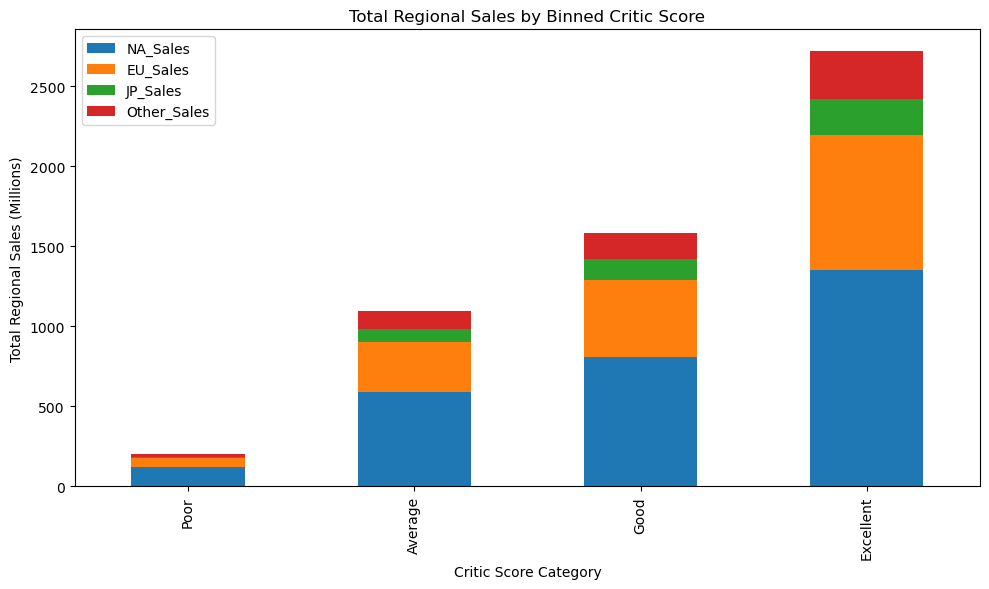

In [138]:
total_regional_sales_by_bin = df_clean.groupby('Score_Bin')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
total_regional_sales_by_bin.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Total Regional Sales by Binned Critic Score')
plt.xlabel('Critic Score Category')
plt.ylabel('Total Regional Sales (Millions)')
plt.tight_layout()
plt.show()

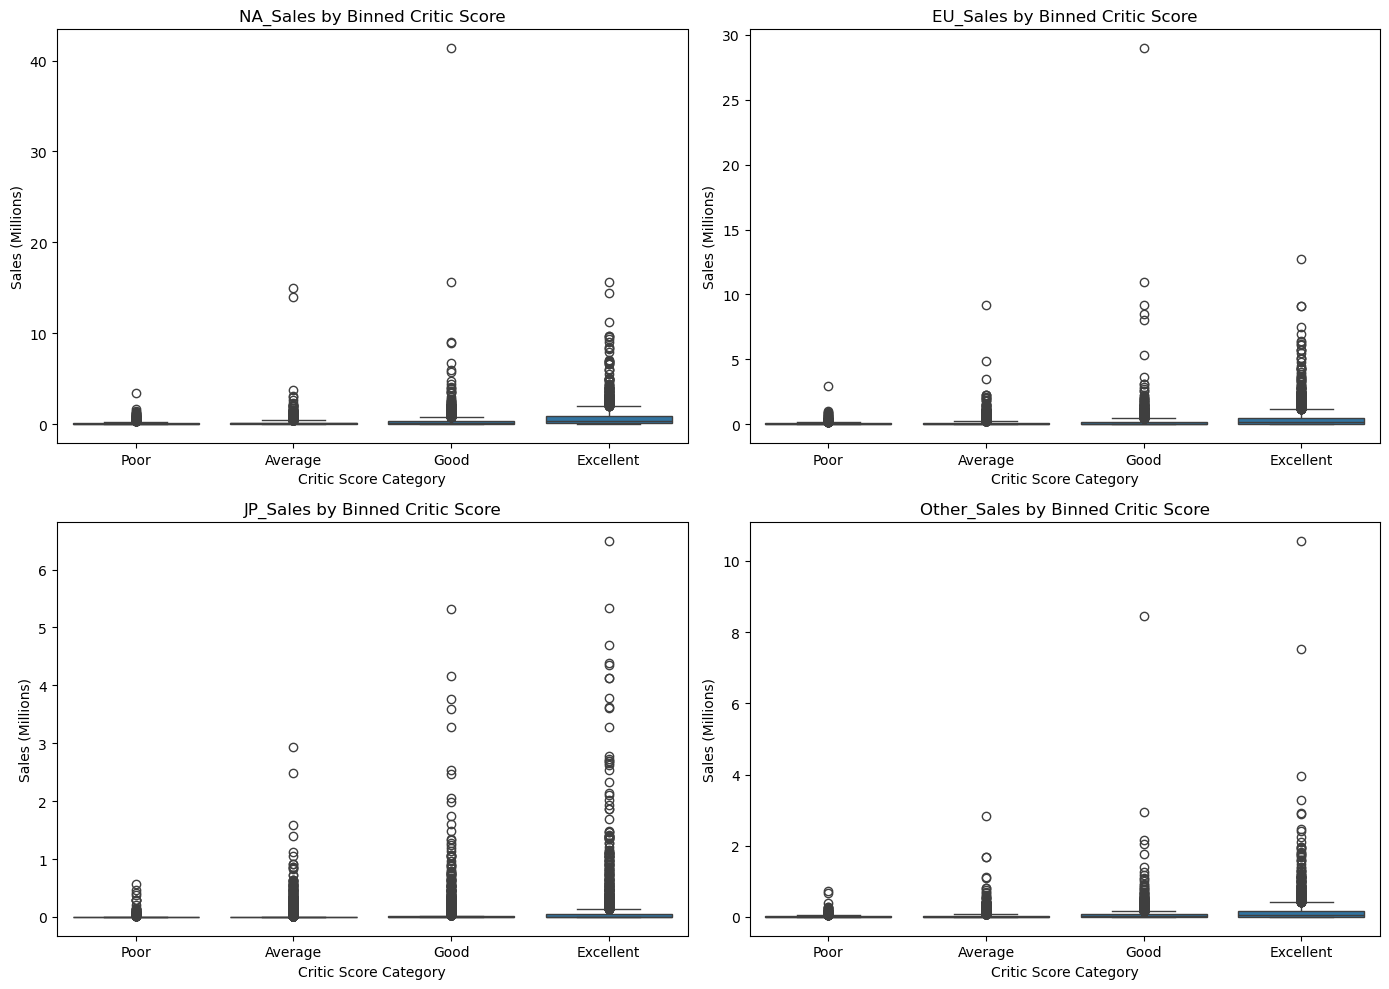

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

for i, region in enumerate(regions):
    sns.boxplot(data=df_clean, x='Score_Bin', y=region, ax=axes[i])
    axes[i].set_title(f'{region} by Binned Critic Score')
    axes[i].set_xlabel('Critic Score Category')
    axes[i].set_ylabel('Sales (Millions)')

plt.tight_layout()
plt.show()

## Final Analysis Notes
This section closes the notebook with a brief wrap-up of the main findings from the analysis.

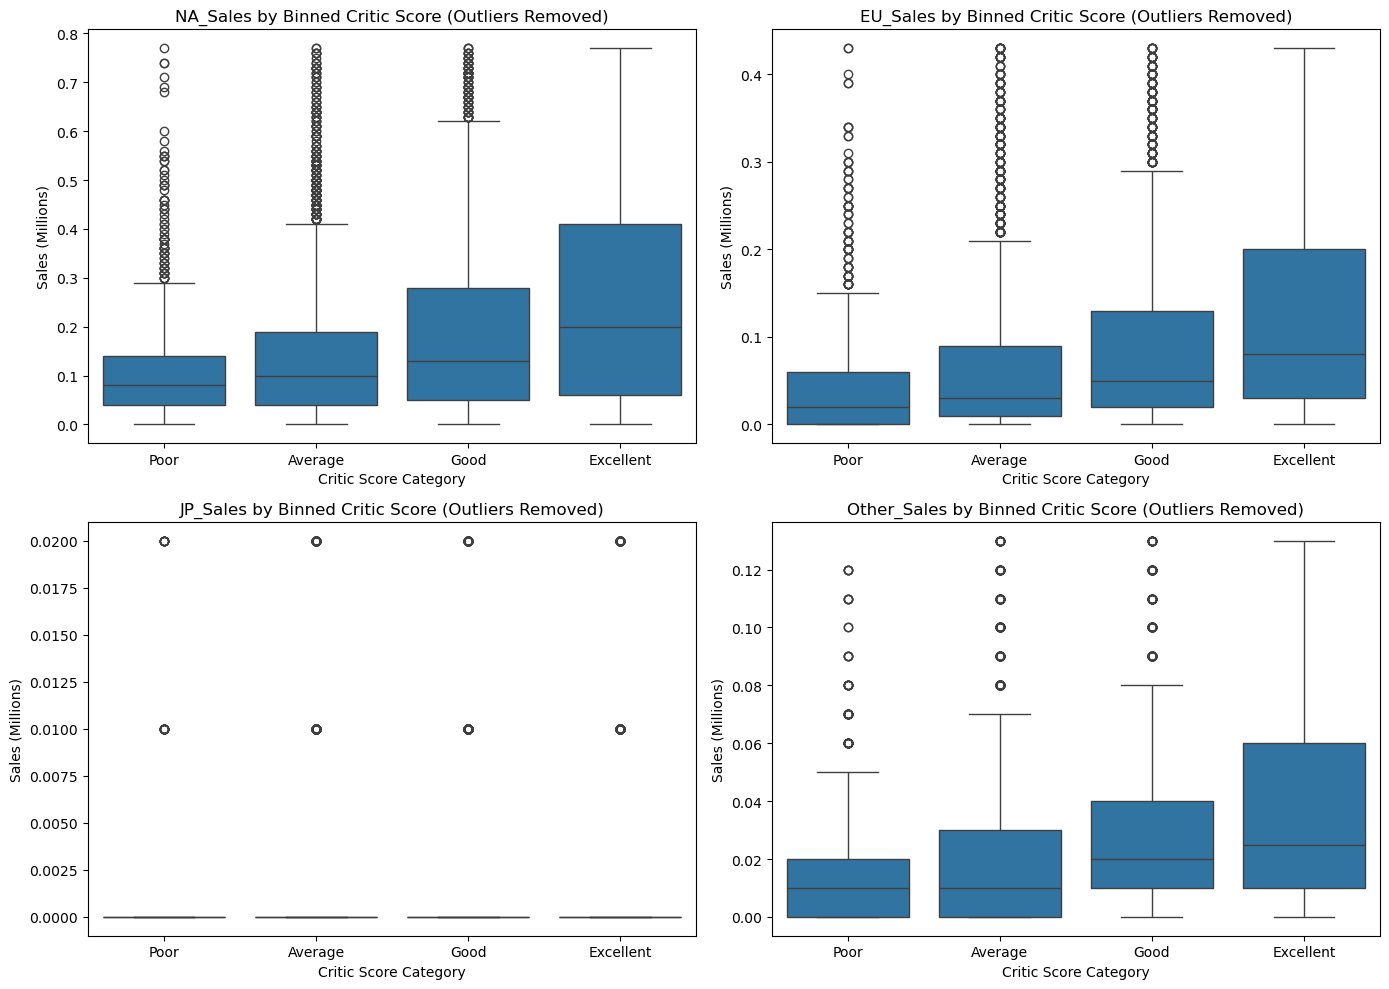

In [140]:
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, region in enumerate(regions):
    df_region = df_clean[['Score_Bin', region]].dropna()

    Q1 = df_region[region].quantile(0.25)
    Q3 = df_region[region].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_filtered = df_region[(df_region[region] >= lower) & (df_region[region] <= upper)]

    sns.boxplot(data=df_filtered, x='Score_Bin', y=region, ax=axes[i])
    axes[i].set_title(f'{region} by Binned Critic Score (Outliers Removed)')
    axes[i].set_xlabel('Critic Score Category')
    axes[i].set_ylabel('Sales (Millions)')

plt.tight_layout()
plt.show()